### SGD Regression on Insurance Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

**1. Dataset Overview**
- Load the dataset insurance.csv.
- Print the first 10 rows to understand its structure and check for null values.
- Identify the features and target variable.

In [2]:
insu = pd.read_csv("C:\\Users\\neera\\Downloads\\insurance(in).csv")
insu

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
insu.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [4]:
insu.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
X = insu.drop("charges", axis=1)
X

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [6]:
y = insu.charges
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

**2. Data Preprocessing**
- Handling missing or null values.
- Encode categorical features (if any) using one-hot encoding or ordinal encoding.
- Normalize or standardize numerical features.
- Perform exploratory data analysis (EDA) to understand the relationship between features and the target variable.

In [7]:
from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=121)

In [38]:
X_train.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
dtype: int64

In [39]:
X_test.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
dtype: int64

In [40]:
X_train

,age,sex,bmi,children,smoker,region
16,52,female,30.780,1,no,northeast
936,44,male,29.735,2,no,northeast
559,19,male,35.530,0,no,northwest
1153,35,female,35.815,1,no,northwest
1221,40,male,24.970,2,no,southeast
...,...,...,...,...,...,...
608,28,male,26.980,2,no,northeast
339,46,female,27.720,1,no,southeast
65,19,female,28.900,0,no,southwest
1288,20,male,39.400,2,yes,southwest


In [41]:
X_test

,age,sex,bmi,children,smoker,region
644,43,male,35.310,2,no,southeast
156,48,male,24.420,0,yes,southeast
15,19,male,24.600,1,no,southwest
432,42,male,26.900,0,no,southwest
20,60,female,36.005,0,no,northeast
...,...,...,...,...,...,...
299,48,female,28.880,1,no,northwest
820,45,male,33.700,1,no,southwest
749,28,male,30.875,0,no,northwest
195,19,male,30.590,0,no,northwest


In [42]:
X_train_num = X_train.select_dtypes(['float'])
X_train_num

,bmi
16,30.780
936,29.735
559,35.530
1153,35.815
1221,24.970
...,...
608,26.980
339,27.720
65,28.900
1288,39.400


In [43]:
impute = SimpleImputer(strategy='median')
impute

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [44]:
impute.fit(X_train_num)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [45]:
impute.statistics_

array([30.305])

In [46]:
X_train_num.describe()




,bmi
count,1070.000000
mean,30.645607
std,6.109391
min,16.815000
25%,26.237500
50%,30.305000
75%,34.770000
max,53.130000


In [47]:
impute.transform(X_train_num)

array([[30.78 ],
       [29.735],
       [35.53 ],
       ...,
       [28.9  ],
       [39.4  ],
       [24.09 ]], shape=(1070, 1))

In [48]:
impute.feature_names_in_

array(['bmi'], dtype=object)

In [49]:
impute.get_feature_names_out()

array(['bmi'], dtype=object)

In [50]:
X_train_num_tr = pd.DataFrame(impute.transform(X_train_num), columns=impute.get_feature_names_out())
X_train_num_tr

,bmi
0,30.780
1,29.735
2,35.530
3,35.815
4,24.970
...,...
1065,26.980
1066,27.720
1067,28.900
1068,39.400


In [51]:
X_train_num_tr.isna().sum()

bmi    0
dtype: int64

In [52]:
X_test

,age,sex,bmi,children,smoker,region
644,43,male,35.310,2,no,southeast
156,48,male,24.420,0,yes,southeast
15,19,male,24.600,1,no,southwest
432,42,male,26.900,0,no,southwest
20,60,female,36.005,0,no,northeast
...,...,...,...,...,...,...
299,48,female,28.880,1,no,northwest
820,45,male,33.700,1,no,southwest
749,28,male,30.875,0,no,northwest
195,19,male,30.590,0,no,northwest


In [53]:
X_test.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
dtype: int64

In [54]:
X_test_num = X_test.select_dtypes('float')
X_test_num

,bmi
644,35.310
156,24.420
15,24.600
432,26.900
20,36.005
...,...
299,28.880
820,33.700
749,30.875
195,30.590


In [55]:
X_test_num_tr = impute.transform(X_test_num)
X_test_num_tr

array([[35.31 ],
       [24.42 ],
       [24.6  ],
       [26.9  ],
       [36.005],
       [37.9  ],
       [25.46 ],
       [27.455],
       [32.67 ],
       [37.4  ],
       [36.3  ],
       [36.385],
       [34.7  ],
       [45.9  ],
       [33.44 ],
       [33.5  ],
       [33.33 ],
       [37.1  ],
       [34.105],
       [37.7  ],
       [31.73 ],
       [31.5  ],
       [30.495],
       [29.48 ],
       [40.3  ],
       [36.29 ],
       [35.8  ],
       [39.16 ],
       [35.625],
       [26.03 ],
       [29.735],
       [39.7  ],
       [25.935],
       [36.86 ],
       [33.63 ],
       [40.5  ],
       [30.115],
       [25.74 ],
       [30.59 ],
       [35.2  ],
       [33.63 ],
       [32.1  ],
       [29.48 ],
       [24.53 ],
       [21.12 ],
       [27.835],
       [22.135],
       [32.3  ],
       [33.88 ],
       [33.63 ],
       [30.2  ],
       [27.55 ],
       [32.11 ],
       [31.24 ],
       [25.6  ],
       [24.64 ],
       [38.38 ],
       [29.64 ],
       [29.7  

In [56]:
X_test_num_tr = pd.DataFrame(X_test_num_tr, columns=impute.get_feature_names_out())
X_test_num_tr

,bmi
0,35.310
1,24.420
2,24.600
3,26.900
4,36.005
...,...
263,28.880
264,33.700
265,30.875
266,30.590


In [57]:
X_test_num_tr.isna().sum()

bmi    0
dtype: int64

In [28]:
Encode categorical features (if any) using one-hot encoding or ordinal encoding.

SyntaxError: invalid syntax (2622647421.py, line 1)



1.ordinal encoding
2.onehot encoding

In [58]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

In [59]:
X_train

,age,sex,bmi,children,smoker,region
16,52,female,30.780,1,no,northeast
936,44,male,29.735,2,no,northeast
559,19,male,35.530,0,no,northwest
1153,35,female,35.815,1,no,northwest
1221,40,male,24.970,2,no,southeast
...,...,...,...,...,...,...
608,28,male,26.980,2,no,northeast
339,46,female,27.720,1,no,southeast
65,19,female,28.900,0,no,southwest
1288,20,male,39.400,2,yes,southwest


In [60]:
X_train_cat = X_train.select_dtypes(['object'])
X_train_cat

,sex,smoker,region
16,female,no,northeast
936,male,no,northeast
559,male,no,northwest
1153,female,no,northwest
1221,male,no,southeast
...,...,...,...
608,male,no,northeast
339,female,no,southeast
65,female,no,southwest
1288,male,yes,southwest


In [61]:
encoder = OrdinalEncoder()
encoder

,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,unknown_value,None
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


In [62]:
encoder.fit(X_train_cat)

,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,unknown_value,None
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


In [63]:
encoder.categories_

[array(['female', 'male'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [64]:
encoder.transform(X_train_cat)

array([[0., 0., 0.],
       [1., 0., 0.],
       [1., 0., 1.],
       ...,
       [0., 0., 3.],
       [1., 1., 3.],
       [0., 0., 2.]], shape=(1070, 3))

In [65]:
X_train_cat

,sex,smoker,region
16,female,no,northeast
936,male,no,northeast
559,male,no,northwest
1153,female,no,northwest
1221,male,no,southeast
...,...,...,...
608,male,no,northeast
339,female,no,southeast
65,female,no,southwest
1288,male,yes,southwest


In [66]:
from sklearn.preprocessing import OneHotEncoder

In [67]:
one_hot = OneHotEncoder()
one_hot

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [68]:
one_hot.fit(X_train_cat)

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [69]:
one_hot.categories_

[array(['female', 'male'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [70]:
sparse_matrix = one_hot.transform(X_train_cat)
sparse_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3210 stored elements and shape (1070, 8)>

In [71]:
one_hot.categories_

[array(['female', 'male'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [72]:
sparse_matrix.toarray()

array([[1., 0., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 1., 0., 0.],
       ...,
       [1., 0., 1., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 1.],
       [1., 0., 1., ..., 0., 1., 0.]], shape=(1070, 8))

In [73]:
one_hot.feature_names_in_

array(['sex', 'smoker', 'region'], dtype=object)

In [74]:
one_hot.get_feature_names_out()

array(['sex_female', 'sex_male', 'smoker_no', 'smoker_yes',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest'], dtype=object)

In [75]:
pd.DataFrame(sparse_matrix.toarray(), columns=one_hot.get_feature_names_out())

,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
1065,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
1066,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1067,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1068,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [76]:
X_train_cat.isna().sum()

sex       0
smoker    0
region    0
dtype: int64

 Normalize or standardize numerical features.

In [77]:
from sklearn.preprocessing import StandardScaler

In [78]:

X_train_num_tr

,bmi
0,30.780
1,29.735
2,35.530
3,35.815
4,24.970
...,...
1065,26.980
1066,27.720
1067,28.900
1068,39.400


In [79]:
X_train_num_tr.isna().sum()

bmi    0
dtype: int64

In [80]:
X_train_num_tr.describe()

,bmi
count,1070.000000
mean,30.645607
std,6.109391
min,16.815000
25%,26.237500
50%,30.305000
75%,34.770000
max,53.130000


In [81]:
scale = StandardScaler()
scale

,copy,True
,with_mean,True
,with_std,True


In [82]:
scale.fit(X_train_num_tr)

,copy,True
,with_mean,True
,with_std,True


In [83]:
scale.mean_

array([30.64560748])

In [84]:
scale.var_

array([37.28978155])

In [85]:
X_test_num_tr_scale = scale.transform(X_test_num_tr)
X_test_num_tr_scale

array([[ 0.76383608],
       [-1.01949903],
       [-0.99002241],
       [-0.6133768 ],
       [ 0.87764856],
       [ 1.1879718 ],
       [-0.8491897 ],
       [-0.52249057],
       [ 0.33151242],
       [ 1.10609232],
       [ 0.92595746],
       [ 0.93987697],
       [ 0.66394312],
       [ 2.49804351],
       [ 0.45760682],
       [ 0.46743236],
       [ 0.43959334],
       [ 1.05696463],
       [ 0.56650653],
       [ 1.15522001],
       [ 0.177579  ],
       [ 0.13991443],
       [-0.02466332],
       [-0.19087867],
       [ 1.58099331],
       [ 0.92431987],
       [ 0.84407798],
       [ 1.39430809],
       [ 0.81542016],
       [-0.7558471 ],
       [-0.14912014],
       [ 1.48273793],
       [-0.7714042 ],
       [ 1.01766248],
       [ 0.48872103],
       [ 1.6137451 ],
       [-0.08689173],
       [-0.80333719],
       [-0.00910622],
       [ 0.7458226 ],
       [ 0.48872103],
       [ 0.23816981],
       [-0.19087867],
       [-1.00148554],
       [-1.55990361],
       [-0

In [86]:
X_test_scale_num_tr_scale = pd.DataFrame(X_test_num_tr_scale, columns=scale.get_feature_names_out())
X_test_num_tr_scale

array([[ 0.76383608],
       [-1.01949903],
       [-0.99002241],
       [-0.6133768 ],
       [ 0.87764856],
       [ 1.1879718 ],
       [-0.8491897 ],
       [-0.52249057],
       [ 0.33151242],
       [ 1.10609232],
       [ 0.92595746],
       [ 0.93987697],
       [ 0.66394312],
       [ 2.49804351],
       [ 0.45760682],
       [ 0.46743236],
       [ 0.43959334],
       [ 1.05696463],
       [ 0.56650653],
       [ 1.15522001],
       [ 0.177579  ],
       [ 0.13991443],
       [-0.02466332],
       [-0.19087867],
       [ 1.58099331],
       [ 0.92431987],
       [ 0.84407798],
       [ 1.39430809],
       [ 0.81542016],
       [-0.7558471 ],
       [-0.14912014],
       [ 1.48273793],
       [-0.7714042 ],
       [ 1.01766248],
       [ 0.48872103],
       [ 1.6137451 ],
       [-0.08689173],
       [-0.80333719],
       [-0.00910622],
       [ 0.7458226 ],
       [ 0.48872103],
       [ 0.23816981],
       [-0.19087867],
       [-1.00148554],
       [-1.55990361],
       [-0

In [87]:
X_test_num_tr

,bmi
0,35.310
1,24.420
2,24.600
3,26.900
4,36.005
...,...
263,28.880
264,33.700
265,30.875
266,30.590


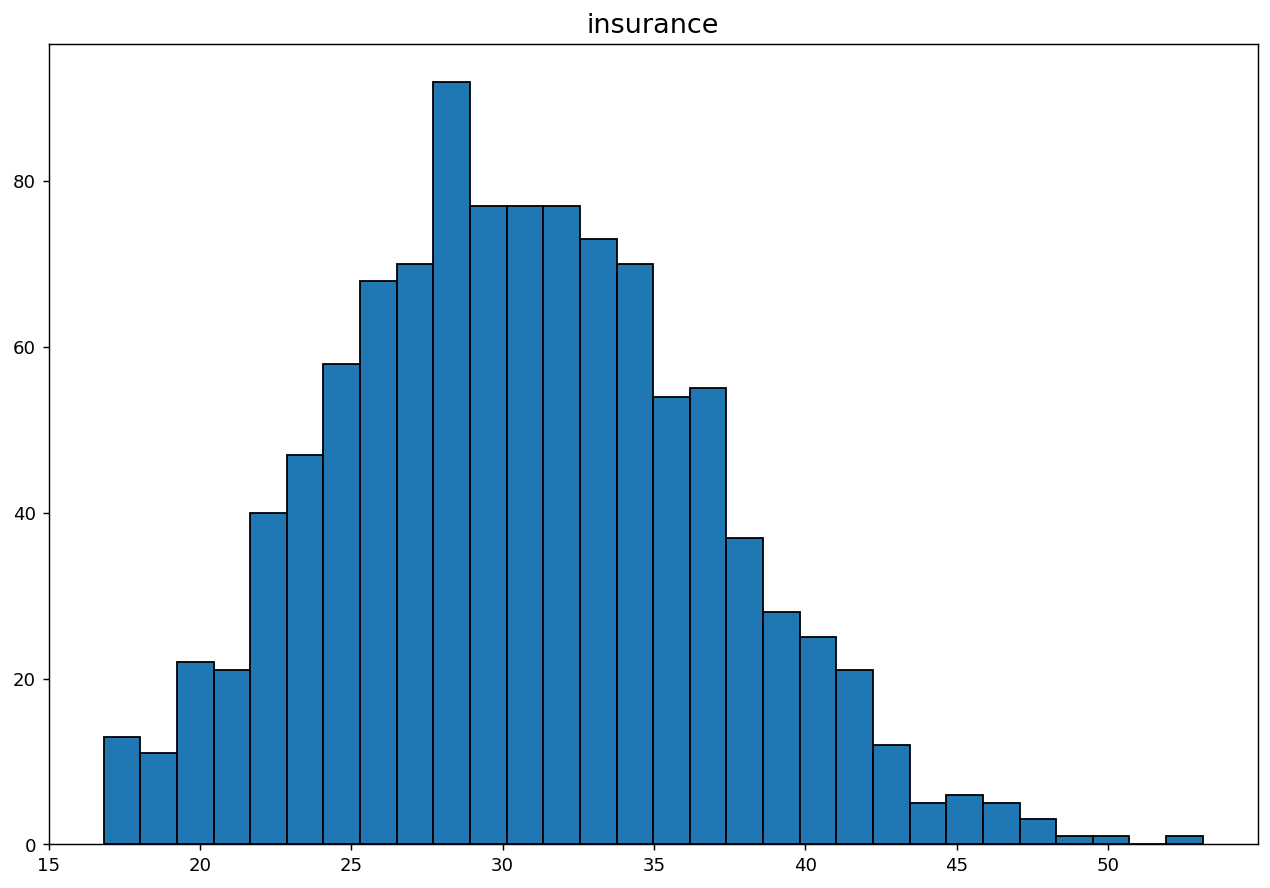

In [88]:
plt.figure(figsize=(12,8),dpi=130)
plt.title("insurance", size=15)

plt.hist(X_train_num_tr['bmi'], bins=30,ec='k')
plt.show()

Perform exploratory data analysis (EDA) to understand the relationship between features and the target variable.

**3. Train-Test Split**
- Divide the dataset into training (80%) and testing (20%) sets using train_test_split.

In [89]:
X

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [90]:
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [91]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1070, 6)
X_test shape: (268, 6)
y_train shape: (1070,)
y_test shape: (268,)


**4. SGD Regression Model**
- Import SGDRegressor from Scikit-learn.
- Train the model on the training data.
- Choose an appropriate loss function (squared_error for regression) and learning rate (eta0).
  - Experiment with different learning rates and compare their impact on the model's performance.
  - Use different numbers of iterations (max_iter) and observe.

In [92]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score


In [93]:
models = [
    ('SGD', SGDRegressor(max_iter=20000, eta0=0.00001, n_iter_no_change=10)),
]

In [94]:
def predict(m,X_train,X_test,y_train,y_test):
    name,model = m
    print(f"Model: {name}")
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print(f"Training Report")
    print(f"Training Error: {mean_absolute_error(y_train, y_train_pred):.2f}")
    print(f"Training Accuracy: {r2_score(y_train,y_train_pred):.2f}")

    print("Test Report")
    print(f"Testing Error: {mean_absolute_error(y_test, y_test_pred):.2f}")
    print(f"Testing Accuracy: {r2_score(y_test,y_test_pred):.2f}")

    


In [95]:

num_cols = X.select_dtypes('float').columns
cat_cols = X.select_dtypes('object').columns
cat1_cols = X.select_dtypes('object').columns



num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

cat1_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])

final_pipeline = ColumnTransformer([
    ('num_pipeline', num_pipeline, num_cols),
    ('cat_pipeline', cat_pipeline, cat_cols),
    ('cat1_pipeline', cat1_pipeline, cat1_cols)
])

final_pipeline.fit(X_train)
X_train_tr = final_pipeline.transform(X_train)
X_test_tr = final_pipeline.transform(X_test)


for i in models:
    predict(i, X_train_tr,X_test_tr,y_train,y_test)
    print()
    

Model: SGD
Training Report
Training Error: 5541.18
Training Accuracy: 0.64
Test Report
Testing Error: 5700.83
Testing Accuracy: 0.65



C:\Users\neera\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [96]:
models = [
    ('SGD', SGDRegressor(max_iter=20000, eta0=0.00001, n_iter_no_change=10)),
]

In [97]:
def predict(m,X_train,X_test,y_train,y_test):
    name,model = m
    print(f"Model: {name}")
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print(f"Training Report")
    print(f"Training Error: {mean_absolute_error(y_train, y_train_pred):.2f}")
    print(f"Training Accuracy: {r2_score(y_train,y_train_pred):.2f}")

    print("Test Report")
    print(f"Testing Error: {mean_absolute_error(y_test, y_test_pred):.2f}")
    print(f"Testing Accuracy: {r2_score(y_test,y_test_pred):.2f}")

    


In [98]:
num_cols = X.select_dtypes('float').columns
cat_cols = X.select_dtypes('object').columns




num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# cat_pipeline = Pipeline([
#     ('impute', SimpleImputer(strategy='most_frequent')),
#     ('encoder', OrdinalEncoder())
# ])
cat1_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])


final_pipeline = ColumnTransformer([
    ('num_pipeline', num_pipeline, num_cols),
    ('cat_pipeline', cat_pipeline, cat_cols)
])

final_pipeline.fit(X_train)
X_train_tr = final_pipeline.transform(X_train)
X_test_tr = final_pipeline.transform(X_test)


for i in models:
    predict(i, X_train_tr,X_test_tr,y_train,y_test)
    print()
    

Model: SGD
Training Report
Training Error: 6382.24
Training Accuracy: 0.50
Test Report
Testing Error: 6464.76
Testing Accuracy: 0.50



C:\Users\neera\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [99]:
Choose an appropriate loss function (squared_error for regression) and learning rate (eta0).
Experiment with different learning rates and compare their impact on the model's performance.
Use different numbers of iterations (max_iter) and observe.
Selection deleted


SyntaxError: unterminated string literal (detected at line 2) (2158725381.py, line 2)

In [ ]:
Choose an appropriate loss function (squared_error for regression) and learning rate (eta0).

In [ ]:
loss = 'squared_error'

SGDRegressor(
    loss='squared_error',
    eta0=0.01,
    learning_rate='constant',
    max_iter=1000,
    random_state=42
)

In [ ]:
Experiment with different learning rates and compare their impact on the model's performance.

In [ ]:
learning_rates = [0.0001,0.001,0.01,0.1]
for lr in learning_rates:
    model = SGDRegressor(
        loss='squared_error',
        eta0=lr,
        learning_rate='constant',
        max_iter=10000,
        random_state=41
    )

    model.fit(X_train_tr, y_train)
    y_test_pred = model.predict(X_test_tr)

    print("Learning Rate:", lr)
    print(f"Testing Error: {mean_absolute_error(y_test, y_test_pred):.2f}")
    print(f"Testing Accuracy: {r2_score(y_test,y_test_pred):.2f}")

    


In [ ]:
Experiment with Different max_iter

In [ ]:
iterations = [1000,5000,10000,20000,40000]

In [ ]:
for itr in iterations:

    model = SGDRegressor(
        loss='squared_error',
        eta0=0.01,
        learning_rate='constant',
        max_iter=itr,
        random_state=42
    )

    model.fit(X_train_tr,y_train)
    y_test_pred = model.predict(X_test_tr)
    # y_train_pred = model.predict(y_train_tr)

    print("Learning Rate:", lr)
    print(f"Testing Error: {mean_absolute_error(y_test, y_test_pred):.2f}")
    print(f"Testing Accuracy: {r2_score(y_test,y_test_pred):.2f}")

    # print(f"Training Report")
    # print(f"Training Error: {mean_absolute_error(y_train, y_train_pred):.2f}")
    # print(f"Training Accuracy: {r2_score(y_train,y_train_pred):.2f}")


    


**5. Model Evaluation**
- Evaluate the model's performance on both training and testing data using regression metrics.
  - What is the R² score for the model on the test set?
  - How does the learning rate affect the model's performance?

In [ ]:
y_train_pred = model.predict(X_train_tr)
y_test_pred = model.predict(X_test_tr)

In [ ]:
print("Training Report")
print("MAE :", mean_absolute_error(y_train,y_train_pred))
print("MSE :", mean_squared_error(y_train,y_train_pred))
print("R2 Score :",r2_score(y_train,y_train_pred))

print("Testing Report")
print("MAE :",mean_absolute_error(y_test,y_test_pred))
print("MSE :",mean_squared_error(y_test,y_test_pred))
print("R2 score :",r2_score(y_test,y_test_pred))

In [100]:
What is the R² score for the model on the test set?

Init signature: set(iterable=(), /)
Docstring:      Build an unordered collection of unique elements.
Type:           type
Subclasses:     LazySet, LazySet, LazySet

In [101]:
The r2 score on the test set is 0.65
this means the model explains approximately 65% of the variance in the target variable

SyntaxError: invalid syntax (3122323356.py, line 1)

In [ ]:
 How does the learning rate affect the model's performance?

In [102]:
1.A very low learning rate (e.g., 0.0001) makes the model learn slowly, which may result in lower accuracy unless enough iterations are used.
2.A moderate learning rate (e.g., 0.01) usually provides the best balance between convergence speed and model performance.
3.A very high learning rate (e.g., 0.1) can cause the optimization to overshoot the best solution, leading to unstable training and reduced accuracy.

SyntaxError: invalid decimal literal (978528907.py, line 1)

**6. Hyperparameter Tuning**
- Use GridSearchCV or RandomizedSearchCV to identify the best hyperparameters
  - Learning rate (eta0)
  - Penalty (l2, l1, or elasticnet)
  - Maximum iterations (max_iter)
 
Report the best parameters and their corresponding scores.

In [103]:
X_train_tr

array([[ 0.02200798,  0.        ,  0.        ,  0.        ],
       [-0.14912014,  1.        ,  0.        ,  0.        ],
       [ 0.79986306,  1.        ,  0.        ,  1.        ],
       ...,
       [-0.28585887,  0.        ,  0.        ,  3.        ],
       [ 1.43361024,  1.        ,  1.        ,  3.        ],
       [-1.07353948,  0.        ,  0.        ,  2.        ]],
      shape=(1070, 4))

In [104]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor


In [105]:
sgd = SGDRegressor(random_state=42)


In [106]:
param_grid = [{
    'eta0':[0.001,0.01,0.05,0.1],
    'penalty':['l2','l1','elasticnet'],
    'max_iter':[1000,5000,10000]
}]

In [107]:
grid_search = GridSearchCV(
    estimator=sgd,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    return_train_score=True,
    n_jobs=-1
)

In [108]:
grid_search.fit(X_train_tr,y_train)


,estimator,SGDRegressor(random_state=42)
,param_grid,"[{'eta0': [0.001, 0.01, ...], 'max_iter': [1000, 5000, ...], 'penalty': ['l2', 'l1', ...]}]"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,loss,'squared_error'


In [110]:
grid_search.best_params_

{'eta0': 0.05, 'max_iter': 1000, 'penalty': 'l2'}

In [111]:
grid_search.best_estimator_

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


In [112]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
sgd = SGDRegressor(random_state=42)


In [ ]:
param_grid = [{
    'eta0':[0.001,0.01,0.05,0.1],
    'penalty':['l2','l1','elasticnet'],
    'max_iter':[1000,5000,10000]
}]

In [ ]:
random_search = RandomizedSearchCV(estimator=sgd,param_distributions=param_grid,n_iter=10,cv=7,scoring='r2', return_train_score=True)
random_search

In [ ]:
random_search.fit(X_train_tr,y_train)

In [ ]:
random_search.best_estimator_

In [ ]:
random_search.best_params_

In [ ]:
grid_search.best_params_

In [ ]:
grid_search.cv

In [113]:
grid_search.best_score_

np.float64(0.6501014172467594)

In [ ]:
result = grid_search.cv_results_
result

In [ ]:
7*5*4

In [ ]:
result['mean_fit_time'].size

In [ ]:
result.keys()

In [ ]:
result['std_fit_time'].size